# Capire la discesa del gradiente



Per prima cosa, serve una funzione e serve il suo gradiente (o derivata se siamo nel mondo delle funzioni univariate).

Il modo più semplice è definire due funzioni (Python) indipendenti, una per $f$ e una per $f'$.

Ad esempio, per la funzione
$$ f(x) = x^2 + 5x + 6$$
con derivata
$$ f'(x)= 2x + 5 $$

In [1]:
def function(x):
  return x**2 + 5*x + 6

def derivative(x):
  return 2*x + 5

Si potrebbe provare un approccio più "raffinato", calcolando in automatico la derivata, data la funzione iniziale. Ci sono (almeno) due approcci possibili:

- Calcolo simbolico, utilizzando il modulo SymPy:

In [2]:
import sympy as sp

# Definiamo la variabile simbolica
x = sp.Symbol('x')

# Definiamo la funzione f(x)
f = x**2 + 5*x + 6

# Calcoliamo la derivata
f_derivata = sp.diff(f, x)

# Stampiamo il risultato
print("f(x) = ",f)
print("f'(x) = ", f_derivata)

print(type(f))

# Per calcolare f in un punto
# print(f(3))  # Questo è un errore

print(f.subs(x, 3))

f_numeric = sp.lambdify(x, f) # Converte in funzione Python
f_deriv_numeric = sp.lambdify(x, f_derivata)

print(type(f_numeric))

print(f_numeric(3))

f(x) =  x**2 + 5*x + 6
f'(x) =  2*x + 5
<class 'sympy.core.add.Add'>
30
<class 'function'>
30


Per derivare una funzione data dall'utente:

In [3]:
f_expr = input("Inserisci f(x): ")  # Esempio: x**3 + 2*x**2 - 5*x + 1
f = sp.sympify(f_expr)  # Converte la stringa in un'espressione simbolica
f_derivata = sp.diff(f, x)

print(f"f'(x) = {f_derivata}")

Inserisci f(x):  x**2


f'(x) = 2*x


- Approccio numerico

Si può usare il medoto delle differenze finite per la stima della derivata in un punto



$$ f'(x)\simeq \frac{f(x+h)−f(x)}{h} $$​

o quello, generalmente migliore, delle differenze centrate:


$$ f'(x)\simeq \frac{f(x+h)−f(x-h)}{2h} $$​


In [6]:
def derivata(f, x, h=1e-5, metodo="centrale"):
    """Calcola la derivata numerica di f in x usando il metodo delle differenze finite."""
    if metodo == "avanti":
        return (f(x + h) - f(x)) / h
    elif metodo == "indietro":
        return (f(x) - f(x - h)) / h
    elif metodo == "centrale":
        return (f(x + h) - f(x - h)) / (2 * h)

# Esempio di utilizzo:
def f(x):
    return x**2 + 5*x - 6  # Funzione da derivare

x0 = 3  # Punto in cui calcolare la derivata

print(f"f'({x0}) (centrale) = {derivata(f, x0, metodo='centrale')}")
print(f"f'({x0}) (avanti) = {derivata(f, x0, metodo='avanti')}")
print(f"f'({x0}) (indietro) = {derivata(f, x0, metodo='indietro')}")


f'(3) (centrale) = 11.00000000011647
f'(3) (avanti) = 11.000010000117298
f'(3) (indietro) = 10.999990000115643


Detto ciò, ecco il metodo di discesa del gradiente:

$$ x_{n+1} = x_n - \alpha \cdot \frac{df(x_n)}{dx}$$

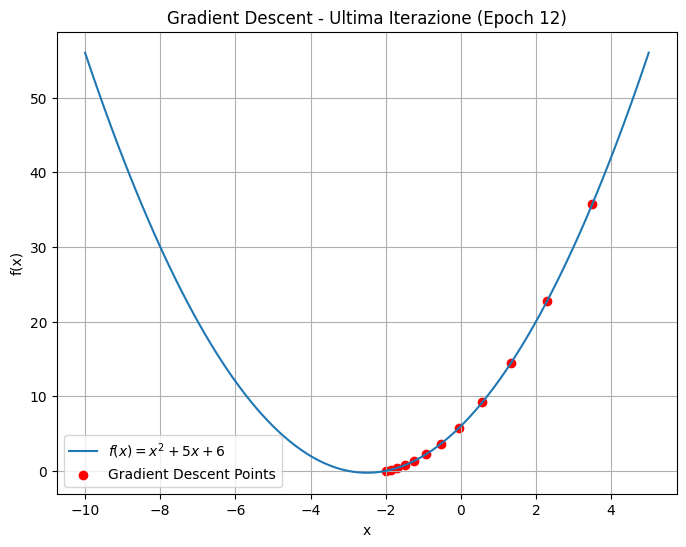

-1.98460392448

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Funzione di costo
def function(x):
    return x**2 + 5*x + 6

# Derivata della funzione
def derivative(x):
    return 2*x + 5

# Gradient Descent
def gradient_descent(initial_x, learning_rate, epochs):
    x = initial_x
    x_vals = []
    f_vals = []

    for _ in range(epochs):
        gradient = derivative(x)
        x = x - learning_rate * gradient
        x_vals.append(x)
        f_vals.append(function(x))

    # Plot solo dell'ultima iterazione
    plt.figure(figsize=(8, 6)) # dimensione in pollici - larghezza- altezza
    plt.title(f"Gradient Descent - Ultima Iterazione (Epoch {epochs})")
    plt.xlabel('x')
    plt.ylabel('f(x)')

    # Disegna la funzione
    x_range = np.linspace(-10, 5, 100)
    plt.plot(x_range, function(x_range), label='$f(x) = x^2 + 5x + 6$')

    # Disegna i punti del gradient descent
    plt.scatter(x_vals, f_vals, color='red', label='Gradient Descent Points')
    plt.legend()
    plt.grid(True)

    plt.show()
    return x

gradient_descent(5, 0.1, 12)


Dal blog, il grafico di tutte le iterazioni:

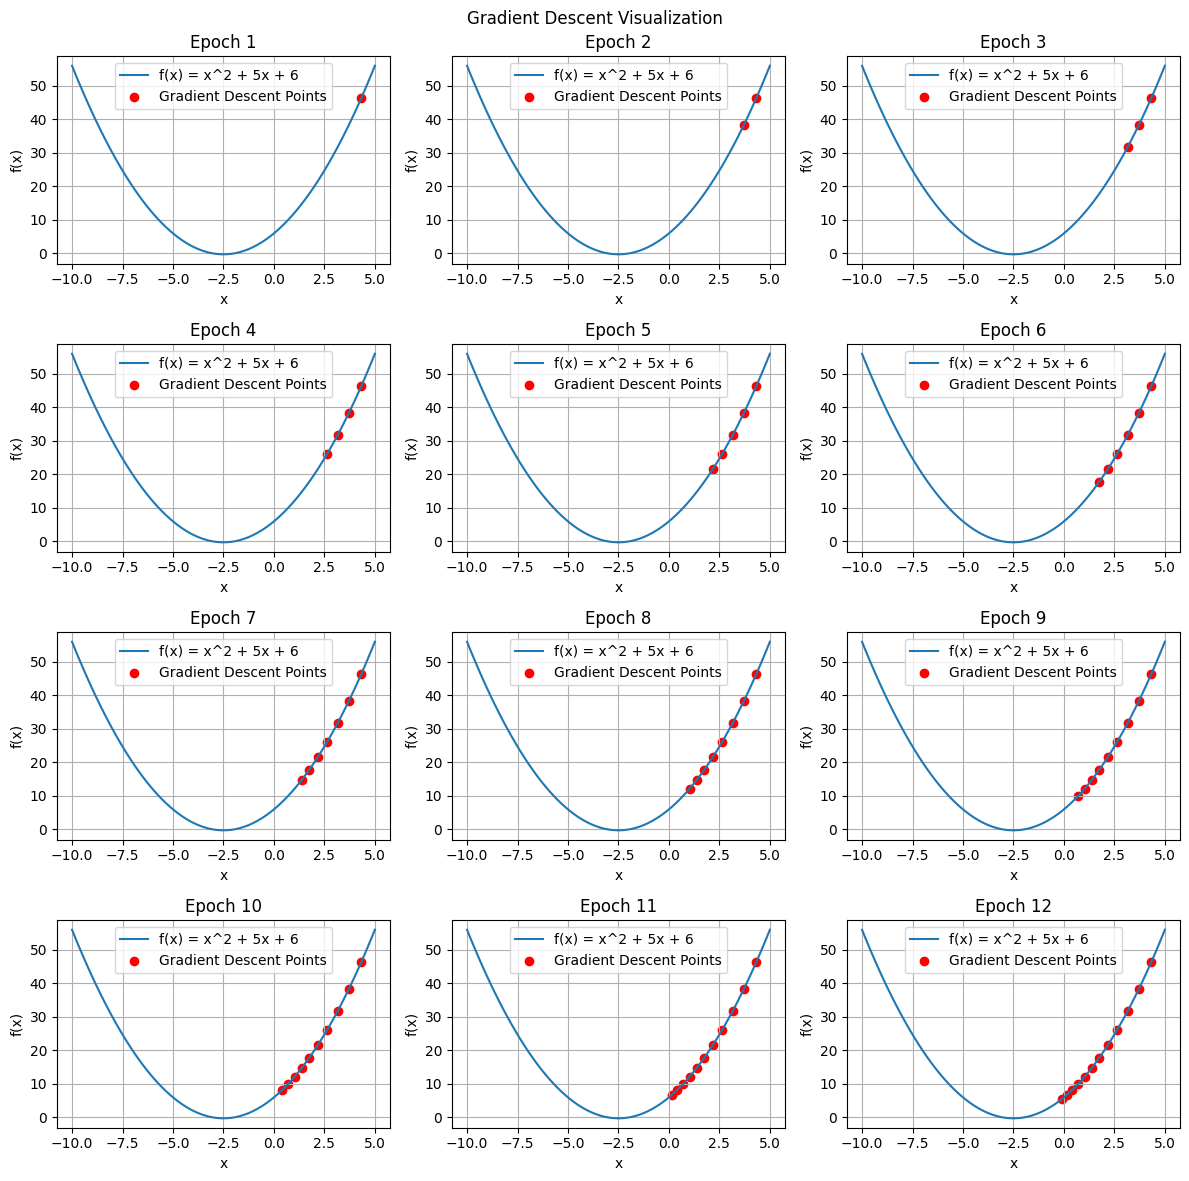

-0.08143384439796417

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# our cost function. you can try it with various samples.maybe you can take 3rd degree equalities.
def function(x):
    return x**2 + 5*x + 6

# derivative of our functions is 2*x + 5. if you want, you can use numpy functions to take derivatives.
def derivative(x):
    return 2*x + 5

# Gradient Descent function. In here, in every step, I tried to visualize the gradient point.
#it takes 3 parameter. where to start, my step size and epoch(iteration)
def gradient_descent(initial_x, learning_rate, epochs):
    x = initial_x
    x_vals = []
    f_vals = []

    fig, axs = plt.subplots(4, 3, figsize=(12, 12))

    fig.suptitle('Gradient Descent Visualization')

    for epoch in range(epochs):

        #this two lines is the gradient descent algorithm.
        # the other lines of function is to draw useful figures for blog :)
        gradient = derivative(x)
        x = x - learning_rate * gradient

        # my values for plotting
        x_vals.append(x)
        f_vals.append(function(x))

        # Calculate subplot index
        row = epoch // 3
        col = epoch % 3

        # Plotting the function and points for the current epoch
        axs[row, col].set_title(f"Epoch {epoch + 1}")
        axs[row, col].set_xlabel('x')
        axs[row, col].set_ylabel('f(x)')

        # Plot the function
        x_range = np.linspace(-10, 5, 100)  # Adjust the range for the function plot
        axs[row, col].plot(x_range, function(x_range), label='f(x) = x^2 + 5x + 6')

        # Plot the points on the function
        axs[row, col].scatter(x_vals, f_vals, color='red', label='Gradient Descent Points')
        axs[row, col].legend()
        axs[row, col].grid(True)


    plt.tight_layout()
    plt.show()

    return x


gradient_descent(5, 0.045, 12)

# Discesa del gradiente in dimensione maggiore

Ottimizzare l'efficienza di una macchina. Hai un solo parametro modificabile (velocità del veicolo) per minimizzare il consumo di carburante. Modificando la velocità leggeremente, si osserva come vari l'efficienza, fino a trovare la velocità ottimale.

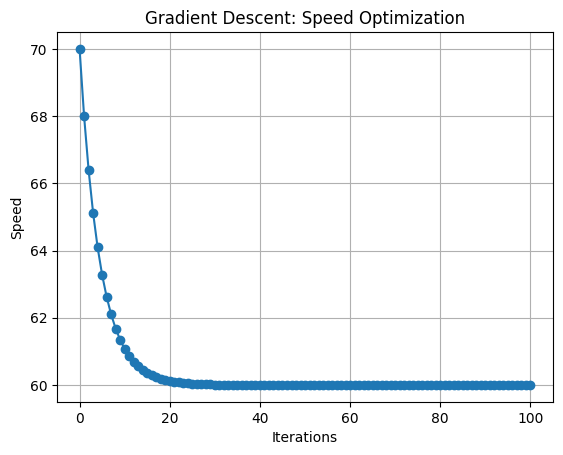

In [16]:
import numpy as np

# this is just a sample. I think that if speed is x, (x-60)^2+50 is our equivalent.
# for gradient descent, also we have to take its derivative.
# note, we do not use fuel efficiency function. just a note.
def fuel_efficiency(speed):
    return (speed - 60)**2 + 50

def efficiency_derivative(speed):
    return 2 * (speed - 60)

# As we know from my other blog about Gradient Descent, here is basic algorithm.

def gradient_descent_1d(speed_init, learning_rate, epochs):
    speed = speed_init
    speed_values = [speed]  # To store speed values for visualization
    for _ in range(epochs):
        gradient = efficiency_derivative(speed)
        speed = speed - learning_rate * gradient
        speed_values.append(speed)  # Append speed for visualization
    return speed_values

# I take a custom static initial start point as 70. you can change to try.
# or you can set a random value set with randn function.
initial_speed = 70
learning_rate = 0.1
num_epochs = 100
result_1d = gradient_descent_1d(initial_speed, learning_rate, num_epochs)

iterations = np.arange(num_epochs + 1)
plt.plot(iterations, result_1d, marker='o')
plt.xlabel('Iterations')
plt.ylabel('Speed')
plt.title('Gradient Descent: Speed Optimization')
plt.grid(True)
plt.show()

Variante in due dimensioni:



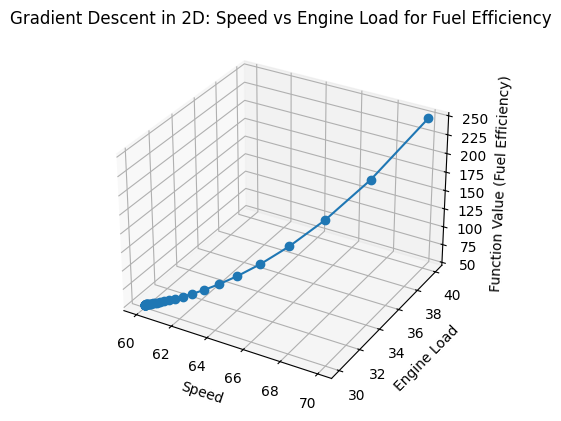

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# my fuel efficiency function
def fuel_efficiency_2d(speed, engine_load):
    return (speed - 60)**2 + (engine_load - 30)**2 + 50

def efficiency_derivative_speed(speed):
    return 2 * (speed - 60)

def efficiency_derivative_load(engine_load):
    return 2 * (engine_load - 30)

# 2D gradient descent
def gradient_descent_2d(speed_init, load_init, learning_rate, epochs):
    speed = speed_init
    load = load_init

    speed_values = [speed] # lines for visualization
    load_values = [load]# lines for visualization
    efficiency_values = [fuel_efficiency_2d(speed, load)] # lines for visualization


    for _ in range(epochs):
        grad_speed = efficiency_derivative_speed(speed) #take speed partial derivative
        grad_load = efficiency_derivative_load(load)# get engine load derivative
        speed = speed - learning_rate * grad_speed # speed independent opt.
        load = load - learning_rate * grad_load #load independent opt.
        speed_values.append(speed)
        load_values.append(load)
        efficiency_values.append(fuel_efficiency_2d(speed, load))

    return speed_values, load_values, efficiency_values

# you can select any other initial values.
initial_speed = 70
initial_load = 40
learning_rate = 0.1
num_epochs = 50
speed_vals, load_vals, efficiency_vals = gradient_descent_2d(initial_speed, initial_load, learning_rate, num_epochs)

# Plotting the 3D graph
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

speed_vals = np.array(speed_vals)
load_vals = np.array(load_vals)
efficiency_vals = np.array(efficiency_vals)

ax.plot(speed_vals, load_vals, efficiency_vals, marker='o')
ax.set_xlabel('Speed')
ax.set_ylabel('Engine Load')
ax.set_zlabel('Function Value (Fuel Efficiency)')
ax.set_title('Gradient Descent in 2D: Speed vs Engine Load for Fuel Efficiency')

plt.show()

Mostrando anche la funzione:

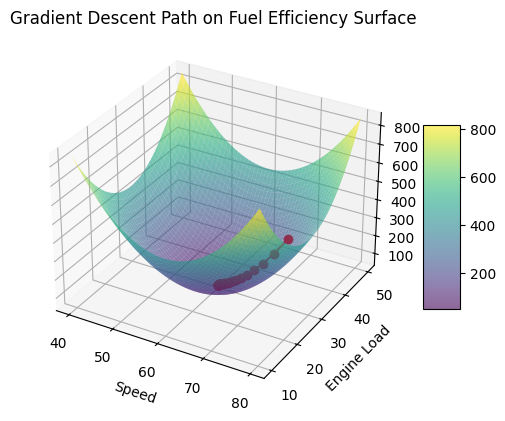

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Fuel efficiency function
def fuel_efficiency_2d(speed, engine_load):
    return (speed - 60)**2 + (engine_load - 30)**2 + 50

# Derivatives
def efficiency_derivative_speed(speed):
    return 2 * (speed - 60)

def efficiency_derivative_load(engine_load):
    return 2 * (engine_load - 30)

# 2D gradient descent
def gradient_descent_2d(speed_init, load_init, learning_rate, epochs):
    speed = speed_init
    load = load_init

    speed_values = [speed]
    load_values = [load]
    efficiency_values = [fuel_efficiency_2d(speed, load)]

    for _ in range(epochs):
        grad_speed = efficiency_derivative_speed(speed)
        grad_load = efficiency_derivative_load(load)
        speed = speed - learning_rate * grad_speed
        load = load - learning_rate * grad_load
        speed_values.append(speed)
        load_values.append(load)
        efficiency_values.append(fuel_efficiency_2d(speed, load))

    return speed_values, load_values, efficiency_values

# Initial values
initial_speed = 70
initial_load = 40
learning_rate = 0.1
num_epochs = 50
speed_vals, load_vals, efficiency_vals = gradient_descent_2d(initial_speed, initial_load, learning_rate, num_epochs)

# Creating the function surface
speed_range = np.linspace(40, 80, 50)
load_range = np.linspace(10, 50, 50)
Speed, Load = np.meshgrid(speed_range, load_range)
Efficiency = fuel_efficiency_2d(Speed, Load)

# Plotting the 3D graph
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot surface
topo = ax.plot_surface(Speed, Load, Efficiency, cmap='viridis', alpha=0.6)
fig.colorbar(topo, ax=ax, shrink=0.5, aspect=5)

# Plot gradient descent path
speed_vals = np.array(speed_vals)
load_vals = np.array(load_vals)
efficiency_vals = np.array(efficiency_vals)
ax.plot(speed_vals, load_vals, efficiency_vals, marker='o', color='r')

ax.set_xlabel('Speed')
ax.set_ylabel('Engine Load')
ax.set_zlabel('Fuel Efficiency')
ax.set_title('Gradient Descent Path on Fuel Efficiency Surface')

plt.show()


Si può rendere il grafico più interattivo usando plotly?

Chat GPT:
*Sì! Il grafico 3D che hai creato con matplotlib è già interattivo per impostazione predefinita quando eseguito in un ambiente che supporta matplotlib in modalità interattiva (come Jupyter Notebook o uno script Python con plt.show()).*

*Tuttavia, se vuoi un'interattività più fluida e avanzata, puoi usare plotly, che permette di ruotare, zoomare e interagire meglio con la grafica. Ti aggiorno il codice per usare plotly.*

In [19]:
import numpy as np
import plotly.graph_objects as go

# Fuel efficiency function
def fuel_efficiency_2d(speed, engine_load):
    return (speed - 60)**2 + (engine_load - 30)**2 + 50

# Derivatives
def efficiency_derivative_speed(speed):
    return 2 * (speed - 60)

def efficiency_derivative_load(engine_load):
    return 2 * (engine_load - 30)

# 2D gradient descent
def gradient_descent_2d(speed_init, load_init, learning_rate, epochs):
    speed = speed_init
    load = load_init

    speed_values = [speed]
    load_values = [load]
    efficiency_values = [fuel_efficiency_2d(speed, load)]

    for _ in range(epochs):
        grad_speed = efficiency_derivative_speed(speed)
        grad_load = efficiency_derivative_load(load)
        speed = speed - learning_rate * grad_speed
        load = load - learning_rate * grad_load
        speed_values.append(speed)
        load_values.append(load)
        efficiency_values.append(fuel_efficiency_2d(speed, load))

    return speed_values, load_values, efficiency_values

# Initial values
initial_speed = 70
initial_load = 40
learning_rate = 0.1
num_epochs = 50
speed_vals, load_vals, efficiency_vals = gradient_descent_2d(initial_speed, initial_load, learning_rate, num_epochs)

# Creating the function surface
speed_range = np.linspace(40, 80, 50)
load_range = np.linspace(10, 50, 50)
Speed, Load = np.meshgrid(speed_range, load_range)
Efficiency = fuel_efficiency_2d(Speed, Load)

# Create interactive 3D surface plot
fig = go.Figure()
fig.add_trace(go.Surface(z=Efficiency, x=Speed, y=Load, colorscale='viridis', opacity=0.7))

# Add gradient descent path
fig.add_trace(go.Scatter3d(x=speed_vals, y=load_vals, z=efficiency_vals,
                            mode='markers+lines', marker=dict(size=5, color='red'),
                            name='Gradient Descent Path'))

fig.update_layout(scene=dict(
    xaxis_title='Speed',
    yaxis_title='Engine Load',
    zaxis_title='Fuel Efficiency'),
    title='Interactive Gradient Descent Path on Fuel Efficiency Surface')

fig.show()
